In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

from agent_based_model import load_data, preprocess_data, \
                                set_initial_values, main_function
from main_pool import Main
from calibr_funcs import plot_results
from hybrid_abm_to_seir import ABC_Agent, generate_synthetic_data

import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day

%load_ext autoreload
%autoreload 2

plt.style.use("default")

In [2]:
# generate synthetic data with known parameters for testing
true_alpha = 0.78
true_lmbd = 0.4

days=range(1, 250)
data_p = 'check2/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''
observed_data = pd.read_csv(f'results/{data_p}/observed.csv')

In [3]:
observed_data

,S_H1N1,E_H1N1,I_H1N1,R_H1N1,beta_H1N1,S_H3N2,E_H3N2,I_H3N2,R_H3N2,beta_H3N2,S_B,E_B,I_B,R_B,beta_B
0,620346.0,6.0,10.0,174974.0,1.612004e-06,620362.0,0.0,0.0,174971.0,NaN,620362.0,0.0,0.0,174970.0,NaN
1,620328.0,24.0,10.0,174974.0,0.000000e+00,620362.0,0.0,0.0,174970.0,NaN,620362.0,0.0,0.0,174967.0,NaN
2,620311.0,35.0,16.0,174974.0,6.045355e-07,620362.0,0.0,0.0,174968.0,NaN,620362.0,0.0,0.0,174964.0,NaN
3,620278.0,50.0,34.0,174974.0,8.535072e-07,620362.0,0.0,0.0,174959.0,NaN,620362.0,0.0,0.0,174959.0,NaN
4,620173.0,138.0,51.0,174974.0,5.374844e-07,620362.0,0.0,0.0,174935.0,NaN,620362.0,0.0,0.0,174933.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
245,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
246,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
247,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## History Matching

In [4]:
# create ABC object
observed_prv = observed_data[['I_H1N1']].rename(columns={'I_H1N1':'H1N1'})
abc = ABC_Agent(observed_prv, data_path=data_p, days=days)

# define parameter ranges for priors
prior_ranges = {"alpha": (0.5, 0.9), # susceptibility
                "lmbd": (0.1, 0.5)  # transmissibility
                }
# run History Matching
hm_results = abc.history_matching(prior_ranges, n_samples=191,
                                 prepared=True)

Loading and preprocessing data...
Running ABM history matching with 191 samples...


ABM History Matching: 100%|██████████| 191/191 [00:02<00:00, 69.40it/s]

Distance stats: min=29512107.235742968, max=7845765250.468303, mean=965279144.1811808
ABM History matching accepted 38 parameter sets


In [5]:
for param in ['alpha', 'lmbd']:
    print(hm_results[param].min(), hm_results[param].max())
    print(param, hm_results[param].quantile(.25), 
          hm_results[param].quantile(.75))
    print()

0.5 0.95
alpha 0.6 0.8375

0.2 0.9
lmbd 0.325 0.5



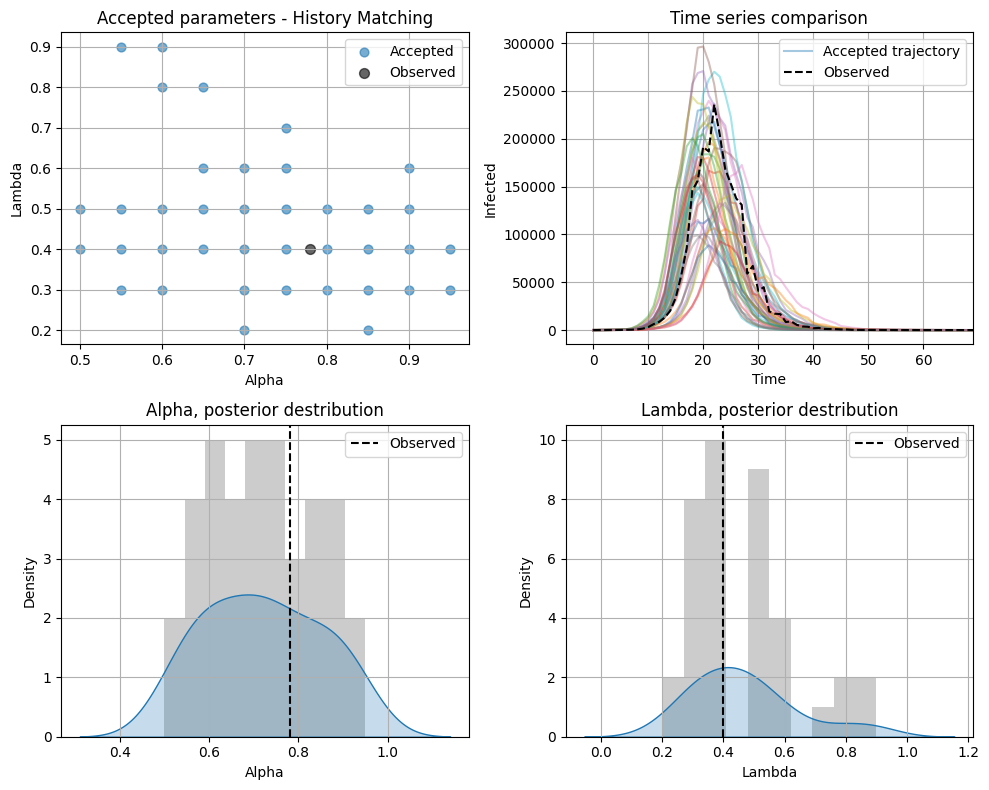

In [7]:
plot_results(observed_prv, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_alpha=true_alpha, true_lmbd=true_lmbd)

(-5.0, 75.0)

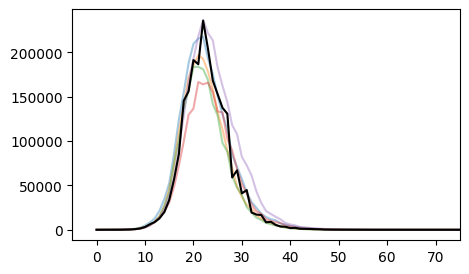

In [8]:
plt.subplots(1, 1, figsize=(5, 3))

for i in range(5):
    plt.plot(hm_results.iloc[i].trajectory, alpha=0.4)
plt.plot(observed_prv, color='black')
plt.xlim(-5, 75)

In [23]:
# choosing accepted params
hm_u_files =  hm_results.iloc[:,:2].apply(lambda x: f"alpha_{x['alpha']}_lmbd_{x['lmbd']}", 
                            axis=1).values

#all_I = pd.DataFrame()
all_b = pd.DataFrame()

for f in hm_u_files:
    seeds = glob.glob(f'chelyabinsk_0.3_sampled/{f}*.csv')
    for seed in seeds:
        df = pd.read_csv(seed)
        #df_I = df['I_H1N1']
        #all_I = pd.concat([all_I,df_I], axis=1)
        
        df_b = df['beta_H1N1']
        all_b = pd.concat([all_b,df_b], axis=1)
        
#all_b.median(axis=1).to_csv('median_beta.csv', index=False)

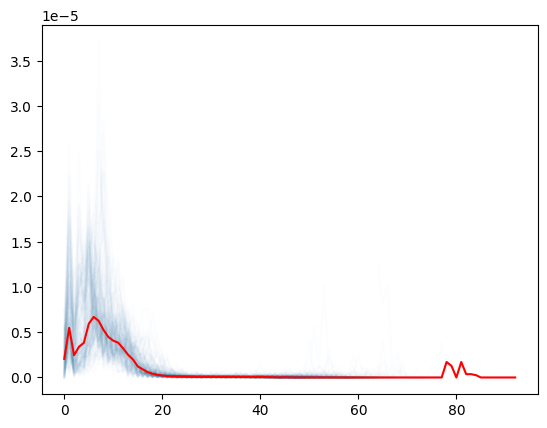

In [24]:
plt.plot(all_b, color='tab:blue', alpha=0.01);
plt.plot(all_b.median(axis=1), color='red')

In [49]:
rejection_results = abc.rejection_abc(n_samples=5, accept_ratio=0.1, 
                                      frac=0.01)

Running ABM ABC rejection with 5 samples...


ABM ABC Rejection: 100%|██████████| 5/5 [07:33<00:00, 90.62s/it]

ABM ABC rejection accepted 1 parameter sets


In [50]:
rejection_results

,alpha,lmbd,distance,trajectory
0,0.8375,0.325,2.012767e+08,0 10.0 1 10.0 2 40.0 3 50....


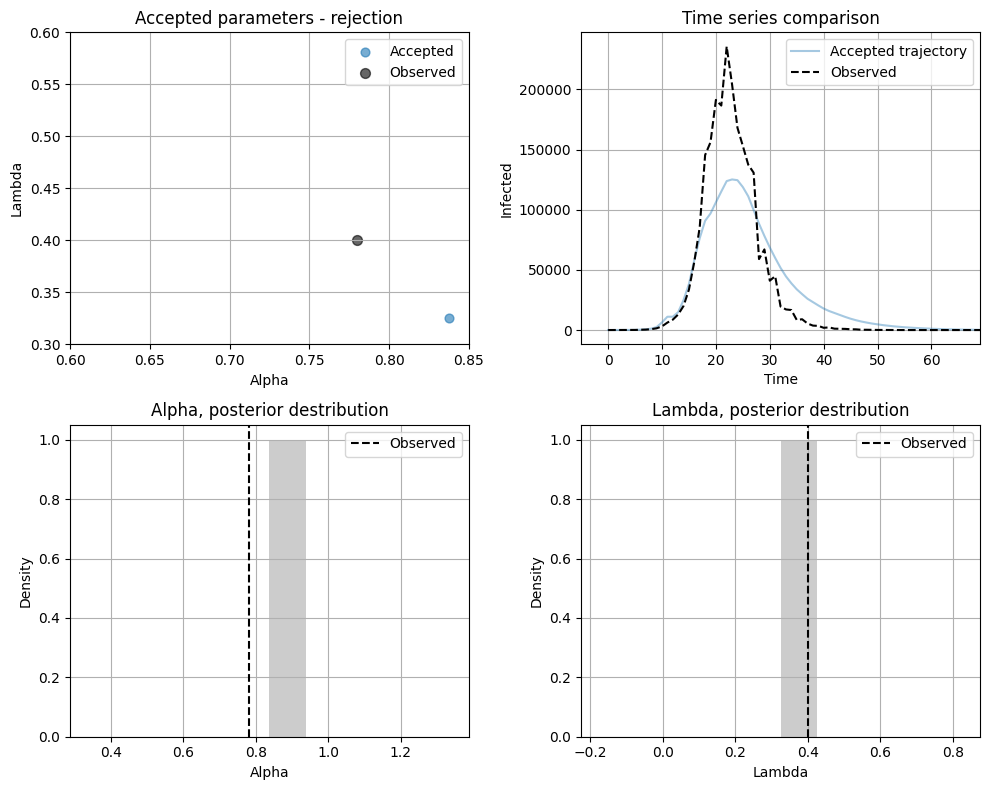

In [64]:
plot_results(observed_prv, rejection_results, 
             "rejection", n_trajectories=len(hm_results),
             true_alpha=true_alpha, true_lmbd=true_lmbd,
            hm_results=hm_results)

In [27]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results = abc.smc_abc(n_particles=10, n_populations=2, 
                          accept_ratio=0.1, 
                          frac=0.001, num_runs=1)

Running ABM ABC-SMC with 2 populations...
ABM SMC Population 1/2, epsilon = 405527461.40


ABM SMC Population 1: 100%|██████████| 10/10 [01:55<00:00, 11.57s/it]


ABM Effective sample size: 5.0
ABM SMC Population 2/2, epsilon = 40977088.05


ABM SMC Population 2: 100%|██████████| 10/10 [02:39<00:00, 15.90s/it]

ABM Effective sample size: 1.0
ABM ABC-SMC completed with 10 particles


In [28]:
smc_results

,alpha,lmbd,weight,distance,trajectory
0,0.814491,0.480516,0.1,2.320519e+08,0 10.0 1 10.0 2 35.0 3 ...
1,0.814491,0.480516,0.1,6.912053e+08,0 10.0 1 10.0 2 35.0 3 ...
2,0.814491,0.480516,0.1,3.926233e+08,0 10.0 1 10.0 2 35.0 3 ...
3,0.814491,0.480516,0.1,1.766769e+08,0 10.0 1 10.0 2 35.0 3 ...
4,0.814491,0.480516,0.1,9.529553e+07,0 10.0 1 10.0 2 35.0 3 ...
5,0.814491,0.480516,0.1,3.425679e+08,0 10.0 1 10.0 2 35.0 3 ...
6,0.814491,0.480516,0.1,5.675300e+08,0 10.0 1 10.0 2 35.0 3 ...
7,0.814491,0.480516,0.1,1.172222e+08,0 10.0 1 10.0 2 35.0 3 ...
8,0.814491,0.480516,0.1,5.918878e+08,0 10.0 1 10.0 2 35.0 3 ...
9,0.814491,0.480516,0.1,4.449263e+08,0 10.0 1 10.0 2 35.0 3 ...


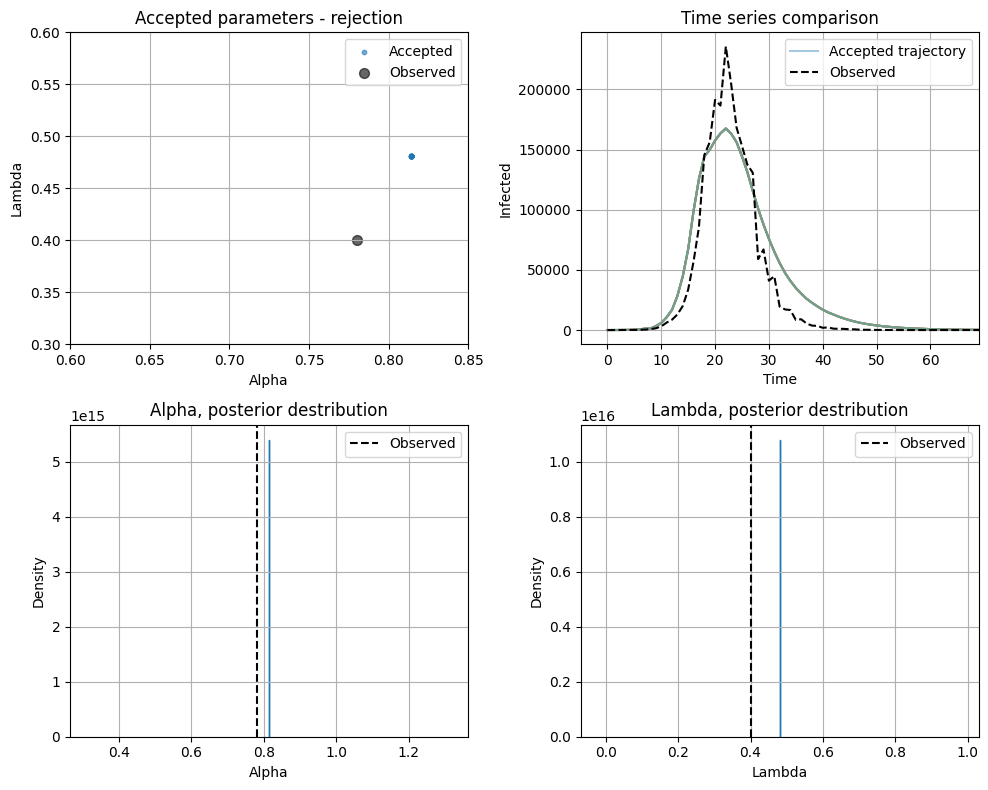

In [29]:
plot_results(observed_prv, smc_results, 
             "rejection", n_trajectories=len(hm_results),
             true_alpha=true_alpha, true_lmbd=true_lmbd, 
            hm_results=hm_results)

Running ABM ABC-SMC with 2 populations...
ABM SMC Population 1/2, epsilon = 405527461.40


ABM SMC Population 1: 100%|██████████| 10/10 [02:31<00:00, 15.17s/it]


ABM Effective sample size: 3.0
ABM SMC Population 2/2, epsilon = 40977088.05


ABM SMC Population 2: 100%|██████████| 10/10 [03:23<00:00, 20.35s/it]


ABM Effective sample size: 1.0
ABM ABC-SMC completed with 10 particles


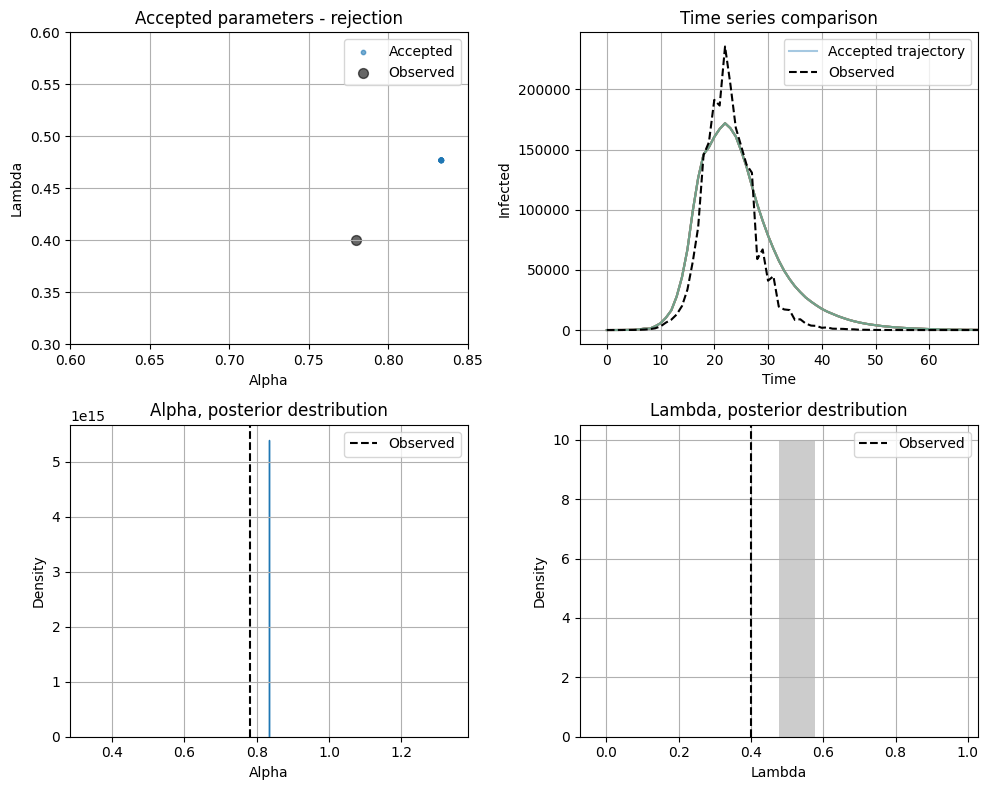

In [25]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results = abc.smc_abc(n_particles=10, n_populations=2, 
                          accept_ratio=0.1, 
                          frac=0.001, num_runs=2)

plot_results(observed_prv, smc_results, 
             "rejection", n_trajectories=len(hm_results),
             true_alpha=true_alpha, true_lmbd=true_lmbd, 
            hm_results=hm_results)

In [26]:
smc_results

,alpha,lmbd,weight,distance,trajectory
0,0.833405,0.476859,0.1,6.355443e+08,0 10.0 1 10.0 2 46.0 3 ...
1,0.833405,0.476859,0.1,9.477494e+07,0 10.0 1 10.0 2 46.0 3 ...
2,0.833405,0.476859,0.1,2.990755e+08,0 10.0 1 10.0 2 46.0 3 ...
3,0.833405,0.476859,0.1,2.476840e+08,0 10.0 1 10.0 2 46.0 3 ...
4,0.833405,0.476859,0.1,4.113632e+08,0 10.0 1 10.0 2 46.0 3 ...
5,0.833405,0.476859,0.1,1.051789e+08,0 10.0 1 10.0 2 46.0 3 ...
6,0.833405,0.476859,0.1,1.806241e+08,0 10.0 1 10.0 2 46.0 3 ...
7,0.833405,0.476859,0.1,1.524694e+08,0 10.0 1 10.0 2 46.0 3 ...
8,0.833405,0.476859,0.1,3.121348e+08,0 10.0 1 10.0 2 46.0 3 ...
9,0.833405,0.476859,0.1,1.663146e+08,0 10.0 1 10.0 2 46.0 3 ...


In [56]:
hm_results['alpha'].quantile(.25)

np.float64(0.6)

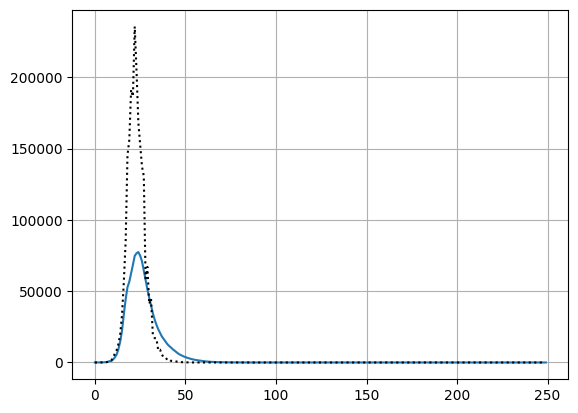

In [9]:
r = abc.run_simulation({'alpha':0.78, 'lmbd':0.4}, 
                   with_switch=True, num_runs=1, fraq=0.001)
plt.plot(r)

plt.plot(observed_prv, ls=':', color='black')
plt.grid()

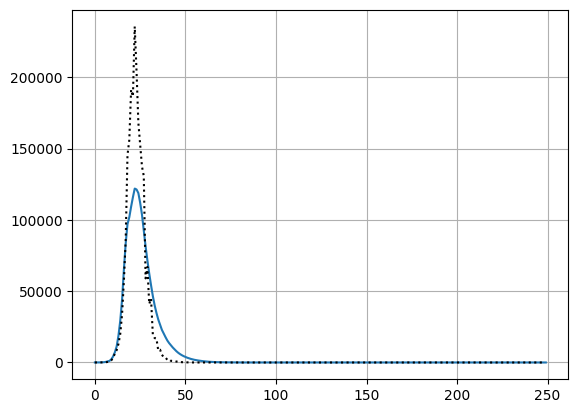

In [14]:
r = abc.run_simulation({'alpha':0.78, 'lmbd':0.4}, 
                   with_switch=True, num_runs=5, fraq=0.001)
plt.plot(r)

plt.plot(observed_prv, ls=':', color='black')
plt.grid()

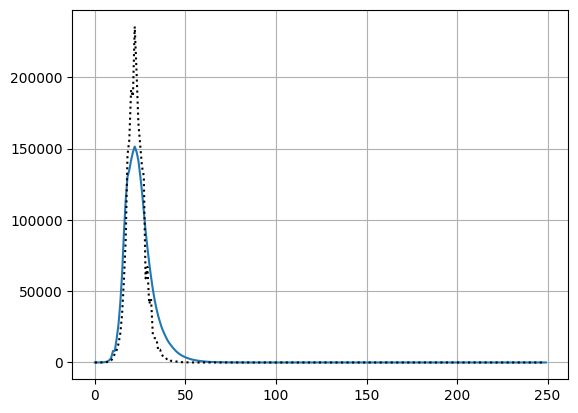

In [15]:
r = abc.run_simulation({'alpha':0.78, 'lmbd':0.4}, 
                   with_switch=True, num_runs=1, fraq=0.01)
plt.plot(r)

plt.plot(observed_prv, ls=':', color='black')
plt.grid()